<a href="https://colab.research.google.com/github/faizankhan-ml/Sentiment-Analysis/blob/main/Supervised_machine_learning_%7C_Python%2C_Pandas%2C_scikit_learn%2C_NLTK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip -q install nltk scikit-learn pandas matplotlib


In [3]:
import nltk
nltk.download("movie_reviews", quiet=True)

import pandas as pd
from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Imports and movie review data are ready.")

Imports and movie review data are ready.


In [4]:
rows = []

for file_id in movie_reviews.fileids():
    category = movie_reviews.categories(file_id)[0]
    sentiment = "Positive" if category == "pos" else "Negative"
    review_text = movie_reviews.raw(file_id)
    rows.append({"review": review_text, "sentiment": sentiment})

feedback = pd.DataFrame(rows)
print("Total labelled reviews:", len(feedback))
print("Reviews per label:")
print(feedback["sentiment"].value_counts())
feedback[["sentiment", "review"]].head(2)


Total labelled reviews: 2000
Reviews per label:
sentiment
Negative    1000
Positive    1000
Name: count, dtype: int64


,sentiment,review
0,Negative,"plot : two teen couples go to a church party ,..."
1,Negative,the happy bastard's quick movie review \ndamn ...


In [5]:
X = feedback["review"]
y = feedback["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training reviews:", len(X_train))
print("Test reviews:", len(X_test))

Training reviews: 1600
Test reviews: 400


In [6]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


Accuracy on held-out movie reviews: 0.812

Classification report:
              precision    recall  f1-score   support

    Negative       0.83      0.79      0.81       200
    Positive       0.80      0.84      0.82       200

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



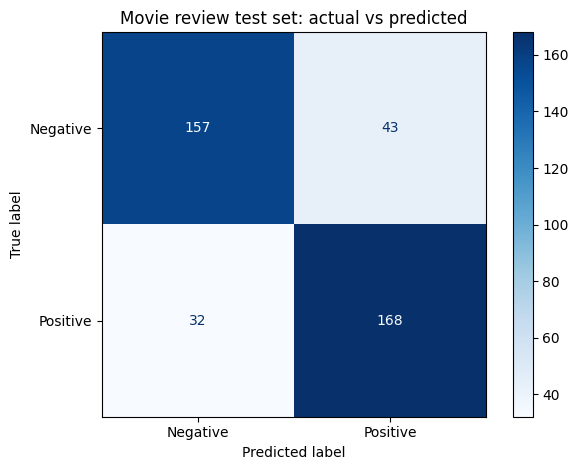

In [7]:
y_pred = model.predict(X_test)

print(f"Accuracy on held-out movie reviews: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=["Negative", "Positive"], cmap="Blues"
)
plt.title("Movie review test set: actual vs predicted")
plt.tight_layout()
plt.show()

In [8]:
def predict_sentiment(review):
    return model.predict([review])[0]

examples = [
    "The performances were excellent and I loved the story.",
    "The plot was dull and the film felt far too long."
]

for review in examples:
    print(f"{predict_sentiment(review)}: {review}")

Positive: The performances were excellent and I loved the story.
Negative: The plot was dull and the film felt far too long.
